<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/ResNet_for_Emotion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [3]:
! pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [4]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [78]:
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes --unzip

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
100% 309M/309M [00:14<00:00, 23.1MB/s]



In [6]:
train_dir = "/content/Emotions Dataset/Emotions Dataset/train"
val_dir = "/content/Emotions Dataset/Emotions Dataset/test"
CLASS_NAME = ["angry", "happy", "sad"]
CONFIGURATION ={
    "BATCH_SIZE" : 32,
    "IMAGE_SIZE" : 224,
    "CHANNELS" : 3,
    "H_EPOCHS" : 10,
    "LEARNING_RATE" : 0.0001,
    "DROPOUT_RATE" : 0.2,
    "REGULARIZATION_RATE" : 0.001,
    "N_FILTER" : 16,
    "KERNEL_SIZE" : 3,
    "POOL_SIZE" : 2,
    "N_STRIDES" : 1,
    "N_PADDING" : "same",
    "N_DENSE_1" : 100,
    "N_DENSE_2" : 10,
    "N_OUTPUT" : 3,
}

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=99,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=99,
)

Found 6799 files belonging to 3 classes.
Found 2278 files belonging to 3 classes.


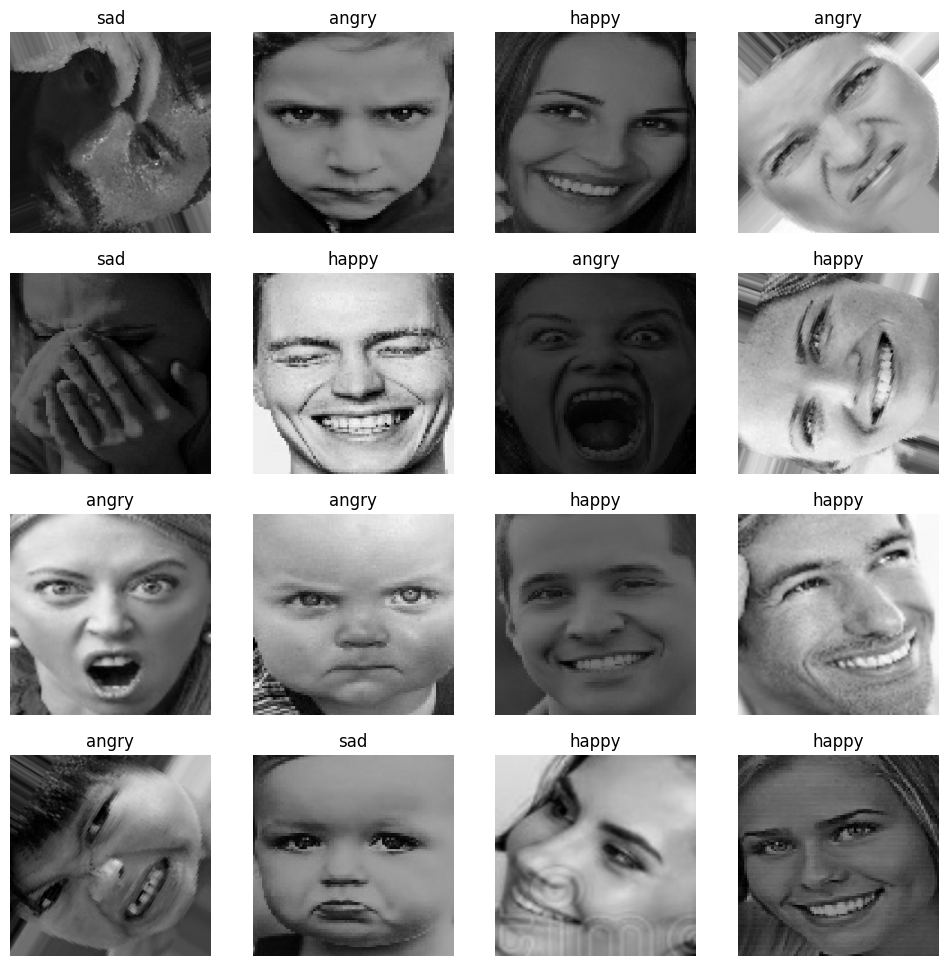

In [8]:
plt.figure(figsize=(12, 12))
for images, labels in train_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title(CLASS_NAME[np.argmax(labels[i])])
    plt.axis("off")

In [9]:
augment_layers = keras.Sequential([
    layers.RandomFlip("horizontal")
])


In [10]:
def augment_layer(image, label):
  return augment_layers(image, training = True), label

In [11]:
traning_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .map(augment_layer, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)
val_dataset = (
    val_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [12]:
for i in train_dataset.take(1):
  print(i)

(<tf.Tensor: shape=(32, 224, 224, 3), dtype=float32, numpy=
array([[[[ 25.      ,  25.      ,  25.      ],
         [ 25.      ,  25.      ,  25.      ],
         [ 24.      ,  24.      ,  24.      ],
         ...,
         [107.      , 107.      , 107.      ],
         [103.      , 103.      , 103.      ],
         [ 99.      ,  99.      ,  99.      ]],

        [[ 24.      ,  24.      ,  24.      ],
         [ 24.      ,  24.      ,  24.      ],
         [ 24.      ,  24.      ,  24.      ],
         ...,
         [109.      , 109.      , 109.      ],
         [105.      , 105.      , 105.      ],
         [102.      , 102.      , 102.      ]],

        [[ 25.      ,  25.      ,  25.      ],
         [ 25.      ,  25.      ,  25.      ],
         [ 25.      ,  25.      ,  25.      ],
         ...,
         [107.      , 107.      , 107.      ],
         [103.      , 103.      , 103.      ],
         [100.      , 100.      , 100.      ]],

        ...,

        [[ 11.      ,  11.      

In [13]:
from tensorflow.keras.layers import Resizing, Rescaling

resize_rescale_layers = tf.keras.Sequential([
       Resizing(CONFIGURATION["IMAGE_SIZE"], CONFIGURATION["IMAGE_SIZE"]),
       Rescaling(1./255),
])

In [14]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

In [15]:
val_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

ResNet34

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def residual_block(x, filters, stride=1):
    shortcut = x

    # First conv
    x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second conv
    x = layers.Conv2D(filters, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [17]:
def ResNet34(input_shape=(256, 256, 3), num_classes=3):
    inputs = keras.Input(shape=input_shape)

    # Initial layer
    x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    # Block 1 → 64 filters (3 blocks)
    for _ in range(3):
        x = residual_block(x, 64)

    # Block 2 → 128 filters (4 blocks)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Block 3 → 256 filters (6 blocks)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Block 4 → 512 filters (3 blocks)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

In [18]:
model = ResNet34(
    input_shape=(CONFIGURATION["IMAGE_SIZE"], CONFIGURATION["IMAGE_SIZE"], 3),
    num_classes=CONFIGURATION["N_OUTPUT"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,574,403 (82.30 MB)

 Trainable params: 21,557,379 (82.23 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIGURATION["LEARNING_RATE"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIGURATION["H_EPOCHS"]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 117s 352ms/step - accuracy: 0.5023 - loss: 1.0805 - val_accuracy: 0.4939 - val_loss: 1.3447
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 54s 255ms/step - accuracy: 0.6464 - loss: 0.7869 - val_accuracy: 0.6378 - val_loss: 0.8956
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 249ms/step - accuracy: 0.7191 - loss: 0.6545 - val_accuracy: 0.6282 - val_loss: 1.0364
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 250ms/step - accuracy: 0.7756 - loss: 0.5376 - val_accuracy: 0.6892 - val_loss: 0.8407
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 249ms/step - accuracy: 0.8201 - loss: 0.4429 - val_accuracy: 0.7081 - val_loss: 0.9421
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 250ms/step - accuracy: 0.8669 - loss: 0.3510 - val_accuracy: 0.5439 - val_loss: 1.1861
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 250ms/step - accuracy: 0.9009 - loss: 0.2737 - val_accuracy: 0.6501 - val_loss: 1.0425
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 250ms/step - accuracy: 0.9094 - loss: 

In [21]:
import matplotlib.pyplot as plt
def plot_loss_curves(history):
  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  epochs = range(1, len(accuracy)+1)
  plt.plot(epochs, accuracy, "b", label="Training accuracy")
  plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
  plt.title("Training and validation accuracy")
  plt.legend()
  plt.figure()
  plt.plot(epochs, loss, "b", label="Training loss")
  plt.plot(epochs, val_loss, "r", label="Validation loss")
  plt.title("Training and validation loss")
  plt.legend()
  plt.show()

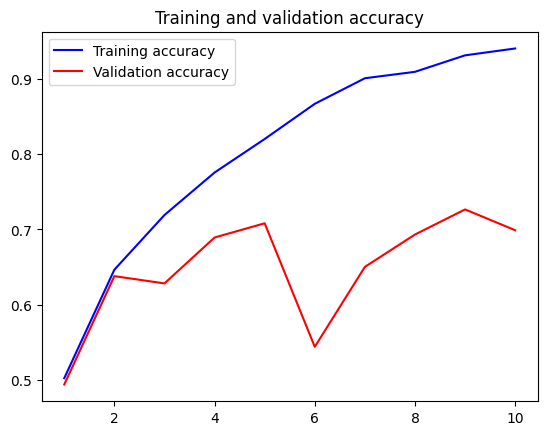

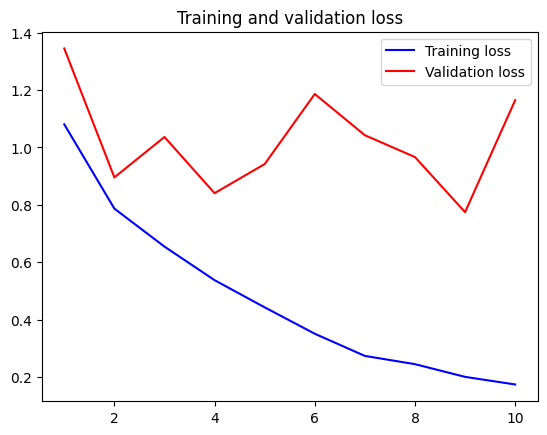

In [22]:
plot_loss_curves(history)

In [23]:
model.evaluate(val_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.6989 - loss: 1.1647


[1.1646969318389893, 0.6988586187362671]

In [52]:
import cv2
def preprocess_image(model):
  test_image = cv2.imread("/content/Emotions Dataset/Emotions Dataset/test/happy/129443.jpg")
  # Convert to RGB if needed (OpenCV loads BGR)
  test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
  print(f"Original image shape: {test_image.shape}")

  # Resize the image to the model's expected input size
  resized_image = tf.image.resize(test_image, [CONFIGURATION["IMAGE_SIZE"], CONFIGURATION["IMAGE_SIZE"]])

  # Convert to float32 and normalize pixel values to [0, 1]
  im = tf.constant(resized_image, dtype= np.float32) / 255.0
  im = tf.expand_dims(im, axis=0)
  print(f"Processed image shape: {im.shape}")
  plt.imshow(im[0])

  prediction = model(im)
  print(f"Model prediction: {prediction}")
  predicted_class_index = np.argmax(prediction)
  print(f"Predicted class index: {predicted_class_index}")
  print(f"Predicted class name: {CLASS_NAME[predicted_class_index]}")

Original image shape: (90, 90, 3)
Processed image shape: (1, 224, 224, 3)
Model prediction: [[0.00438207 0.00170715 0.9939108 ]]
Predicted class index: 2
Predicted class name: sad


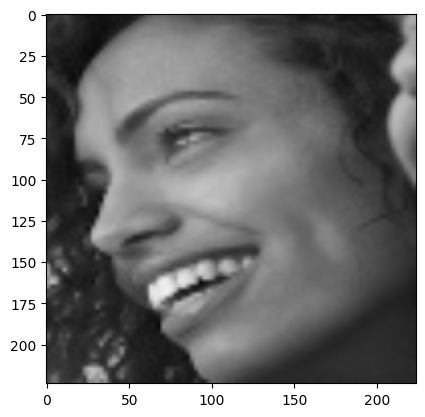

In [53]:
preprocess_image(model)

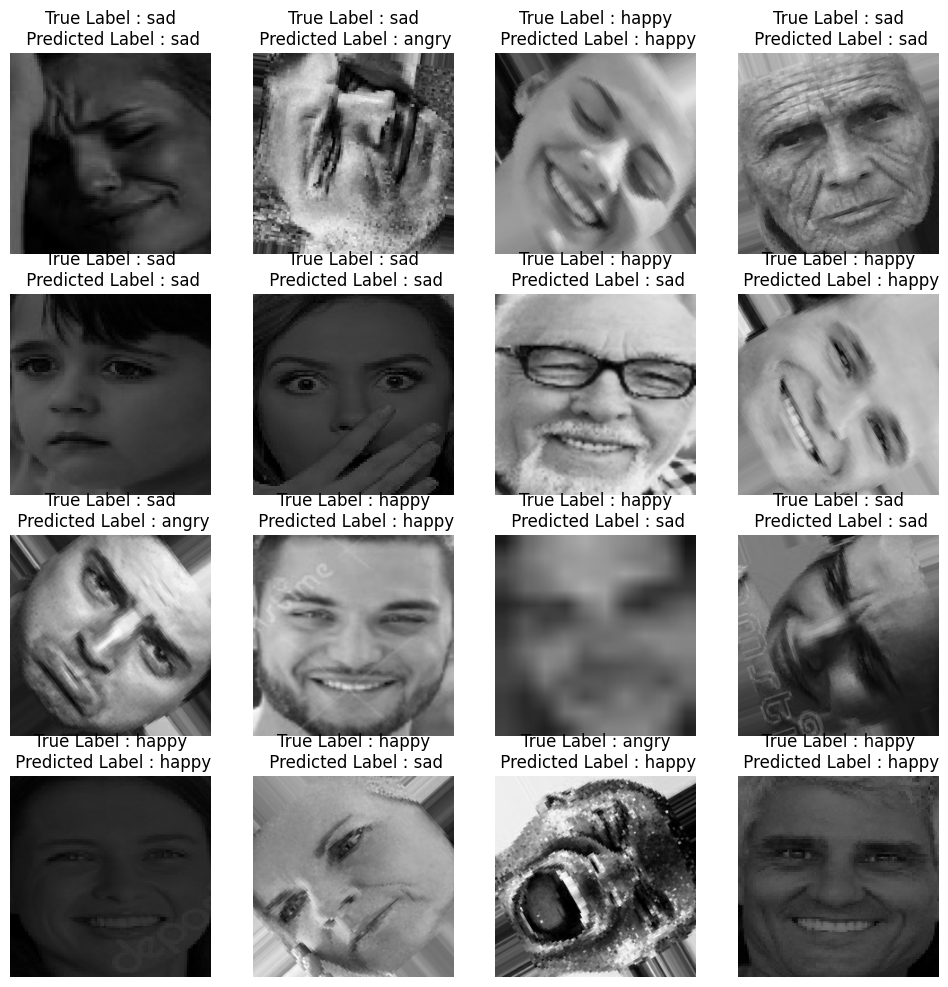

In [28]:
plt.figure(figsize=(12, 12))
for images, labels in val_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title("True Label : " + CLASS_NAME[np.argmax(labels[i])] + "\n" + " Predicted Label : " + CLASS_NAME[np.argmax(model(tf.expand_dims(images[i],axis = 0)))])
    plt.axis("off")

In [29]:
predicted = []
labels = []

for images, label in val_dataset:
    predicted.append((model(images)))
    labels.append(label.numpy())

In [30]:
print(np.argmax(labels[:2], axis = -1))
print(len(labels))
print(len(predicted))

[[1 2 0 2 2 1 2 1 0 1 1 2 1 2 1 1 0 1 0 1 1 1 2 1 2 1 1 0 1 2 1 1]
 [1 1 1 1 0 1 2 1 1 0 2 2 2 1 0 2 1 2 1 1 0 1 0 2 2 1 2 1 2 2 1 1]]
72
72


tf.Tensor(
[[250  53 212]
 [ 36 683 287]
 [ 49  49 659]], shape=(3, 3), dtype=int32)


Text(95.72222222222221, 0.5, 'True Labels')

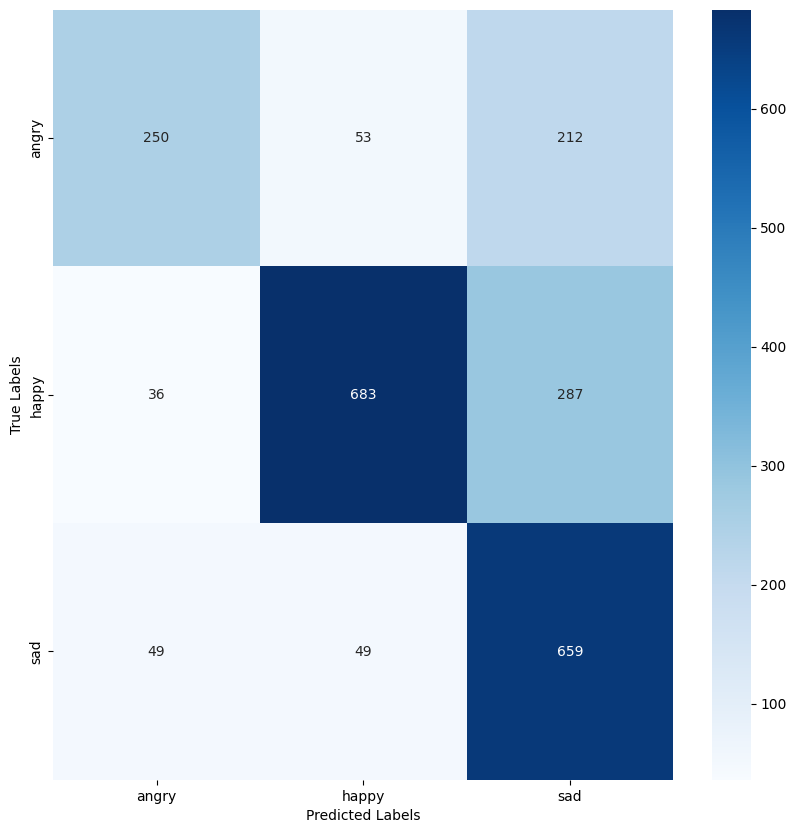

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns

# Concatenate all true one-hot encoded labels into a single NumPy array
all_true_one_hot_labels = np.concatenate(labels, axis=0)

# Concatenate all predicted probability tensors into a single TensorFlow tensor
all_predicted_probabilities = tf.concat(predicted, axis=0)

# Get the class indices for true labels and predicted labels
true_class_indices = np.argmax(all_true_one_hot_labels, axis=-1)
predicted_class_indices = tf.argmax(all_predicted_probabilities, axis=-1)

# Compute the confusion matrix using the 1D arrays of class indices
cm = tf.math.confusion_matrix(true_class_indices, predicted_class_indices)
print(cm)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAME, yticklabels=CLASS_NAME)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

Class Code Model

In [32]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import (GlobalAveragePooling2D, Activation, MaxPooling2D, Add, Conv2D, MaxPool2D, Dense,
                                     Flatten, InputLayer, BatchNormalization, Input, Embedding, Permute,
                                     Dropout, RandomFlip, RandomRotation, LayerNormalization, MultiHeadAttention,
                                     RandomContrast, Rescaling, Resizing, Reshape)
from tensorflow.keras.losses import BinaryCrossentropy,CategoricalCrossentropy, SparseCategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy,TopKCategoricalAccuracy, CategoricalAccuracy, SparseCategoricalAccuracy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (Callback, CSVLogger, EarlyStopping, LearningRateScheduler,
                                        ModelCheckpoint, ReduceLROnPlateau)
from tensorflow.keras.regularizers  import L2, L1

In [33]:
class CustomConv2D(Layer):
  def __init__(self, n_filters, kernel_size, n_strides, padding = 'valid'):
    super(CustomConv2D, self).__init__(name = 'custom_conv2d')

    self.conv = Conv2D(
        filters = n_filters,
        kernel_size = kernel_size,
        activation = 'relu',
        strides = n_strides,
        padding = padding)

    self.batch_norm = BatchNormalization()

  def call(self, x, training = True):

    x = self.conv(x)
    x = self.batch_norm(x, training=training)

    return x

In [34]:
class ResidualBlock(Layer):
  def __init__(self, n_channels, n_strides = 1):
    super(ResidualBlock, self).__init__(name = 'res_block')

    self.dotted = (n_strides != 1)

    self.custom_conv_1 = CustomConv2D(n_channels, 3, n_strides, padding = "same")
    self.custom_conv_2 = CustomConv2D(n_channels, 3, 1, padding = "same")

    self.activation = Activation('relu')

    if self.dotted:
      self.custom_conv_3 = CustomConv2D(n_channels, 1, n_strides)

  def call(self, input, training):

    x = self.custom_conv_1(input, training=training)
    x = self.custom_conv_2(x, training=training)

    if self.dotted:
      x_add = self.custom_conv_3(input, training=training)
      x_add = Add()([x, x_add])
    else:
      x_add = Add()([x, input])

    return self.activation(x_add)

In [35]:
class ResNet34(Model):
  def __init__(self,):
    super(ResNet34, self).__init__(name = 'resnet_34')

    self.conv_1 = CustomConv2D(64, 7, 2, padding = 'same')
    self.max_pool = MaxPooling2D(3,2)

    self.conv_2_1 = ResidualBlock(64)
    self.conv_2_2 = ResidualBlock(64)
    self.conv_2_3 = ResidualBlock(64)

    self.conv_3_1 = ResidualBlock(128, 2)
    self.conv_3_2 = ResidualBlock(128)
    self.conv_3_3 = ResidualBlock(128)
    self.conv_3_4 = ResidualBlock(128)

    self.conv_4_1 = ResidualBlock(256, 2)
    self.conv_4_2 = ResidualBlock(256)
    self.conv_4_3 = ResidualBlock(256)
    self.conv_4_4 = ResidualBlock(256)
    self.conv_4_5 = ResidualBlock(256)
    self.conv_4_6 = ResidualBlock(256)

    self.conv_5_1 = ResidualBlock(512, 2)
    self.conv_5_2 = ResidualBlock(512)
    self.conv_5_3 = ResidualBlock(512)

    self.global_pool = GlobalAveragePooling2D()

    self.fc_3 = Dense(CONFIGURATION["N_OUTPUT"], activation = 'softmax')

  def call(self, x, training = True):
    x = self.conv_1(x, training=training)
    x = self.max_pool(x)

    x = self.conv_2_1(x, training=training)
    x = self.conv_2_2(x, training=training)
    x = self.conv_2_3(x, training=training)

    x = self.conv_3_1(x, training=training)
    x = self.conv_3_2(x, training=training)
    x = self.conv_3_3(x, training=training)
    x = self.conv_3_4(x, training=training)

    x = self.conv_4_1(x, training=training)
    x = self.conv_4_2(x, training=training)
    x = self.conv_4_3(x, training=training)
    x = self.conv_4_4(x, training=training)
    x = self.conv_4_5(x, training=training)
    x = self.conv_4_6(x, training=training)

    x = self.conv_5_1(x, training=training)
    x = self.conv_5_2(x, training=training)
    x = self.conv_5_3(x, training=training)

    x = self.global_pool(x)

    return self.fc_3(x)

In [36]:
resnet_34 = ResNet34()
resnet_34(tf.zeros([1,224,224,3]), training = False)
resnet_34.summary()

Model: "resnet_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_conv2d (CustomConv2D)    │ ?                      │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │       231,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │       296,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │       296,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │       296,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │       921,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     1,182,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     1,182,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     1,182,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     1,182,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     1,182,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     3,677,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     4,723,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block (ResidualBlock)       │ ?                      │     4,723,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 3)                 │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,311,747 (81.30 MB)

 Trainable params: 21,294,723 (81.23 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [37]:
resnet_34.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIGURATION["LEARNING_RATE"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_resnet_34 = resnet_34.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIGURATION["H_EPOCHS"]
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 110s 352ms/step - accuracy: 0.4611 - loss: 1.1657 - val_accuracy: 0.4469 - val_loss: 1.1410
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 55s 257ms/step - accuracy: 0.4873 - loss: 1.0638 - val_accuracy: 0.4548 - val_loss: 1.2531
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 248ms/step - accuracy: 0.5188 - loss: 1.0092 - val_accuracy: 0.4649 - val_loss: 1.3018
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 84s 256ms/step - accuracy: 0.5407 - loss: 0.9667 - val_accuracy: 0.3055 - val_loss: 1.4672
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 247ms/step - accuracy: 0.5574 - loss: 0.9329 - val_accuracy: 0.5158 - val_loss: 1.0500
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 251ms/step - accuracy: 0.6027 - loss: 0.8608 - val_accuracy: 0.5680 - val_loss: 0.9193
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 249ms/step - accuracy: 0.6411 - loss: 0.8070 - val_accuracy: 0.5904 - val_loss: 1.0148
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 251ms/step - accuracy: 0.6808 - loss: 

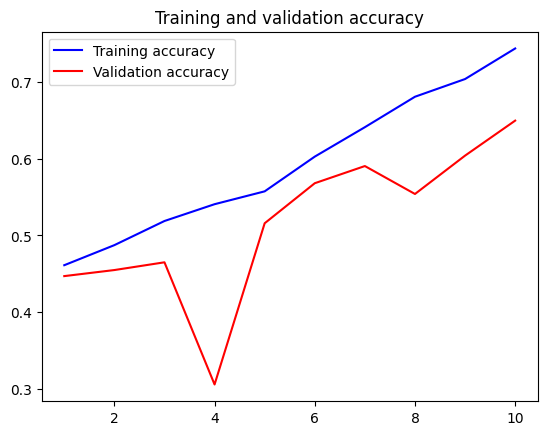

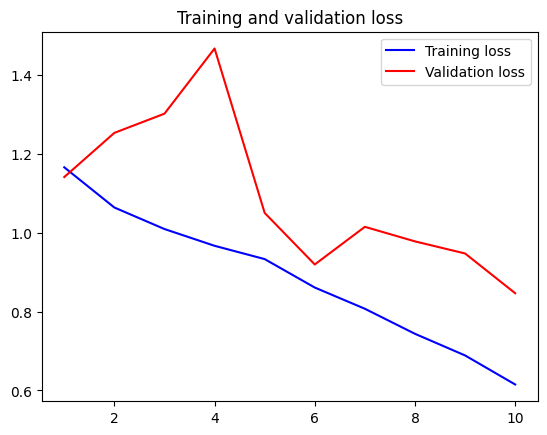

In [39]:
plot_loss_curves(history_resnet_34)

In [40]:
resnet_34.evaluate(val_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6497 - loss: 0.8464


[0.8463867902755737, 0.649692714214325]

Original image shape: (90, 90, 3)
Processed image shape: (1, 224, 224, 3)
Model prediction: [[0.16600858 0.5453709  0.28862056]]
Predicted class index: 1
Predicted class name: happy


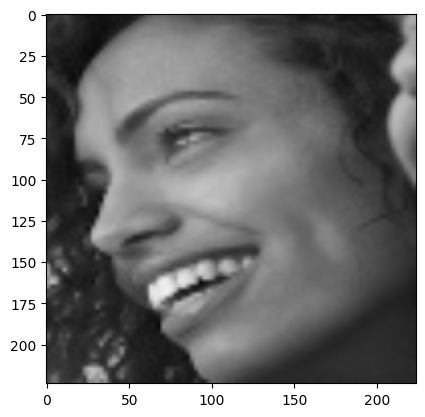

In [54]:
preprocess_image(resnet_34)


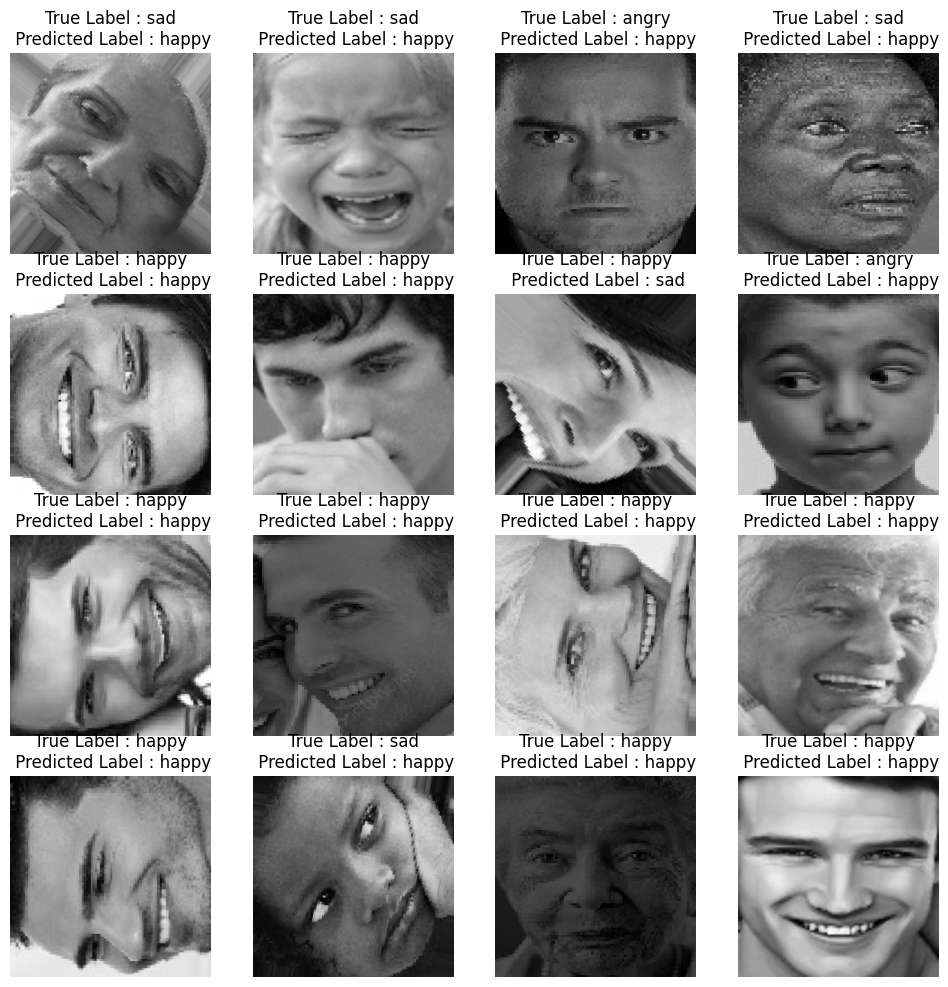

In [42]:
plt.figure(figsize=(12, 12))
for images, labels in val_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title("True Label : " + CLASS_NAME[np.argmax(labels[i])] + "\n" + " Predicted Label : " + CLASS_NAME[np.argmax(resnet_34(tf.expand_dims(images[i],axis = 0)))])
    plt.axis("off")

In [55]:
predicted = []
labels = []

for images, label in val_dataset:
    predicted.append((resnet_34(images)))
    labels.append(label.numpy())

In [56]:
print(np.argmax(labels[:2], axis = -1))
print(len(labels))
print(len(predicted))

[[1 1 1 1 1 0 2 0 1 2 0 0 2 2 1 2 1 2 1 1 2 1 0 1 2 0 1 1 0 1 1 0]
 [0 0 0 1 1 0 1 2 1 1 2 0 2 0 1 1 0 1 1 0 2 2 2 2 1 1 2 2 1 0 1 1]]
72
72


tf.Tensor(
[[252 116 147]
 [ 82 758 166]
 [142 109 506]], shape=(3, 3), dtype=int32)


Text(95.72222222222221, 0.5, 'True Labels')

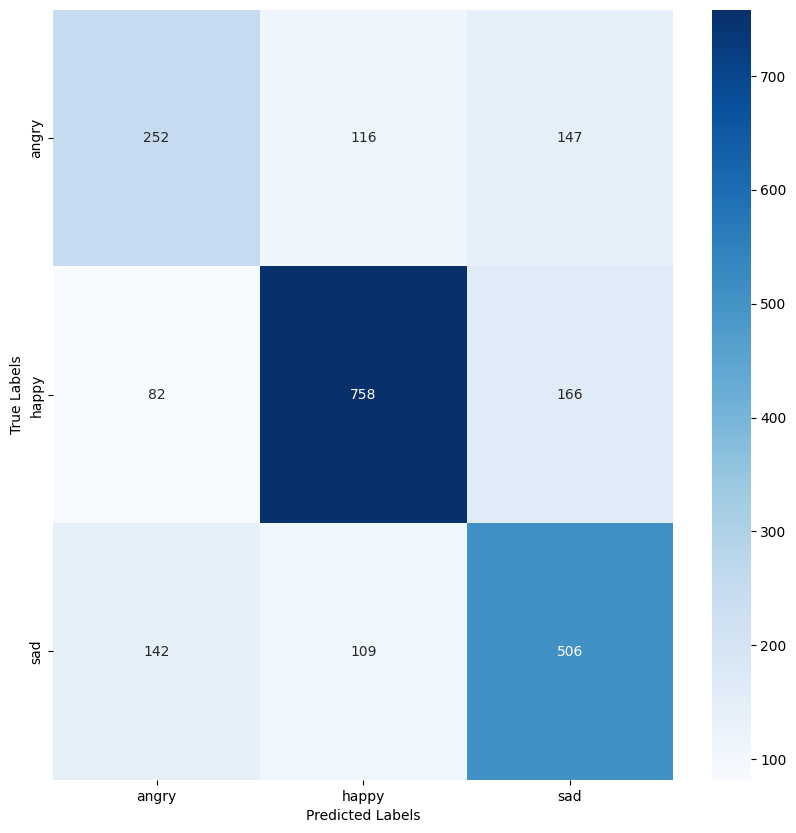

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns

# Concatenate all true one-hot encoded labels into a single NumPy array
all_true_one_hot_labels = np.concatenate(labels, axis=0)

# Concatenate all predicted probability tensors into a single TensorFlow tensor
all_predicted_probabilities = tf.concat(predicted, axis=0)

# Get the class indices for true labels and predicted labels
true_class_indices = np.argmax(all_true_one_hot_labels, axis=-1)
predicted_class_indices = tf.argmax(all_predicted_probabilities, axis=-1)

# Compute the confusion matrix using the 1D arrays of class indices
cm = tf.math.confusion_matrix(true_class_indices, predicted_class_indices)
print(cm)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAME, yticklabels=CLASS_NAME)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')